In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from sympy import *
from sympy.utilities.lambdify import lambdify


In [ ]:
def f(x):
    return x**2

print(f(3))

9


In [3]:
def dfdx(x):
    return 2*x

In [4]:
x_array = np.array([1, 2, 3])

print(f(x_array))

[1 4 9]


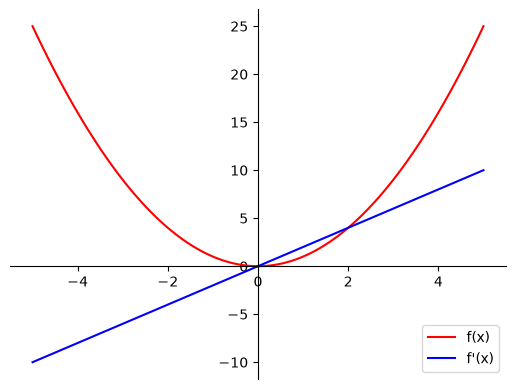

In [5]:
%matplotlib inline

def plot_f1_and_f2(f1, f2=None, x_min=-5, x_max=5, label1="f(x)", label2="f'(x)"):
    x = np.linspace(x_min, x_max,100)

    # Setting the axes at the centre.
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    ax.spines['left'].set_position('center')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    plt.plot(x, f1(x), 'r', label=label1)
    if not f2 is None:
        # If f2 is an array, it is passed as it is to be plotted as unlinked points.
        # If f2 is a function, f2(x) needs to be passed to plot it.        
        if isinstance(f2, np.ndarray):
            plt.plot(x, f2, 'bo', markersize=3, label=label2,)
        else:
            plt.plot(x, f2(x), 'b', label=label2)
    plt.legend()

    plt.show()
    
plot_f1_and_f2(f, dfdx)

In [6]:
one = math.sqrt(18)
two = sqrt(18)

print(f"Math: {one}")
print(f"Sym: {two}")

Math: 4.242640687119285
Sym: 3*sqrt(2)


In [7]:
# Vars need to be defined as symbols
x, y = symbols('x y')
expression = 2*(x**2) - x*y

print(expression)

2*x**2 - x*y


In [8]:
expr_manip = x * (expression + x * y + x**3)

print(expr_manip)
print(expand(expr_manip))

x*(x**3 + 2*x**2)
x**4 + 2*x**3


In [9]:
print(expression.evalf(subs={x:-1, y:2}))

4.00000000000000


In [10]:
f_symb = x ** 2

try:
    f_symb(x_array)
except TypeError as err:
    print(err)

f_symb_numpy = lambdify(x, f_symb, 'numpy')

print(f_symb_numpy(x_array))

'Pow' object is not callable
[1 4 9]


In [11]:
# Finding derivative
print(diff(x**3, x))

3*x**2


In [12]:
dfdx_symb = diff(f_symb, x)
dfdx_symb_numpy = lambdify(x, dfdx_symb, 'numpy')

print("x: \n", x_array)
print("f'(x) = 2x: \n", dfdx_symb_numpy(x_array))

x: 
 [1 2 3]
f'(x) = 2x: 
 [2 4 6]


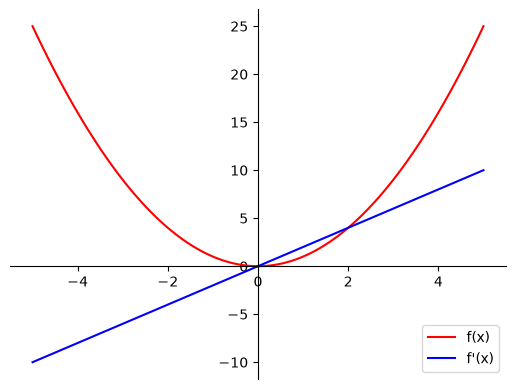

In [13]:
plot_f1_and_f2(f_symb_numpy, dfdx_symb_numpy)

In [14]:
x_array_2 = np.linspace(-5, 5, 100)
print(x_array_2)

[-5.         -4.8989899  -4.7979798  -4.6969697  -4.5959596  -4.49494949
 -4.39393939 -4.29292929 -4.19191919 -4.09090909 -3.98989899 -3.88888889
 -3.78787879 -3.68686869 -3.58585859 -3.48484848 -3.38383838 -3.28282828
 -3.18181818 -3.08080808 -2.97979798 -2.87878788 -2.77777778 -2.67676768
 -2.57575758 -2.47474747 -2.37373737 -2.27272727 -2.17171717 -2.07070707
 -1.96969697 -1.86868687 -1.76767677 -1.66666667 -1.56565657 -1.46464646
 -1.36363636 -1.26262626 -1.16161616 -1.06060606 -0.95959596 -0.85858586
 -0.75757576 -0.65656566 -0.55555556 -0.45454545 -0.35353535 -0.25252525
 -0.15151515 -0.05050505  0.05050505  0.15151515  0.25252525  0.35353535
  0.45454545  0.55555556  0.65656566  0.75757576  0.85858586  0.95959596
  1.06060606  1.16161616  1.26262626  1.36363636  1.46464646  1.56565657
  1.66666667  1.76767677  1.86868687  1.96969697  2.07070707  2.17171717
  2.27272727  2.37373737  2.47474747  2.57575758  2.67676768  2.77777778
  2.87878788  2.97979798  3.08080808  3.18181818  3

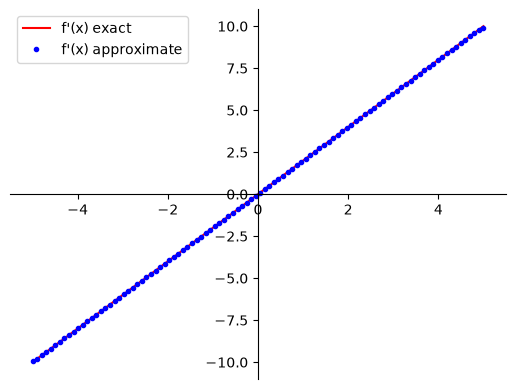

In [15]:
dfdx_diff = np.gradient(f(x_array_2), x_array_2)
dfdx_composed = diff(exp(-2*x) + 3*sin(3*x), x)
plot_f1_and_f2(dfdx_symb_numpy, dfdx_diff, label1="f'(x) exact", label2="f'(x) approximate")

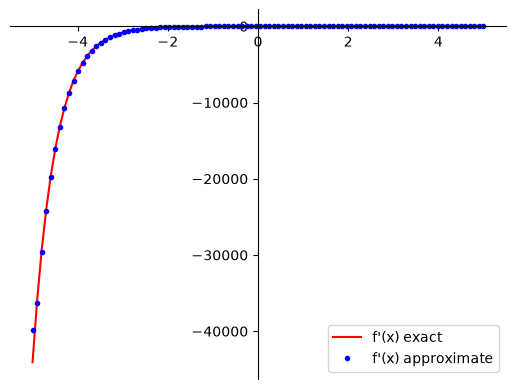

In [16]:
def f_composed(x):
    return np.exp(-2*x) + 3*np.sin(3*x)

plot_f1_and_f2(lambdify(x, dfdx_composed, 'numpy'), np.gradient(f_composed(x_array_2), x_array_2),
              label1="f'(x) exact", label2="f'(x) approximate")

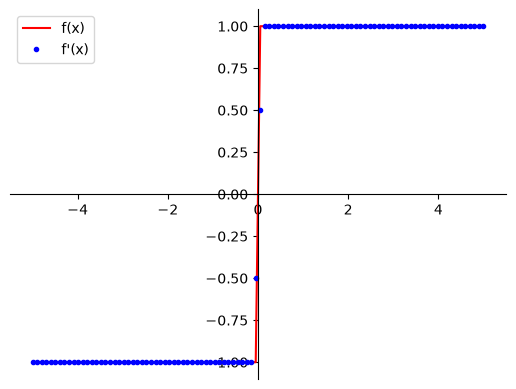

In [17]:
def dfdx_abs(x):
    if x > 0:
        return 1
    else:
        if x < 0:
            return -1
        else:
            return None

plot_f1_and_f2(np.vectorize(dfdx_abs), np.gradient(abs(x_array_2), x_array_2))

You can see that the results near the "jump" are $0.5$ and $-0.5$, while they should be $1$ and $-1$. These cases can give significant errors in the computations.

But the biggest problem with the numerical differentiation is slow speed. It requires function evalutation every time.  In machine learning models there are hundreds of parameters and there are hundreds of derivatives to be calculated, performing full function evaluation every time slows down the computation process. You will see the example of it below.

In [18]:
from jax import grad, vmap
import jax.numpy as jnp

In [24]:
x_array_jnp = jnp.array([1.0,2.0,3.0])

print(f"Typr of numpy: {type(x_array)}")
print(f"Type jax numpy: {type(x_array_jnp)}")

# convert to jax
convert = jnp.array(x_array_jnp.astype('float32'))
print(f"Type jax numpy convert: {type(convert)}")

Typr of numpy: <class 'numpy.ndarray'>
Type jax numpy: <class 'jaxlib._jax.ArrayImpl'>
Type jax numpy convert: <class 'jaxlib._jax.ArrayImpl'>


In [21]:
print(x_array_jnp * 2)
print(x_array_jnp[2])

[2 4 6]
3


In [ ]:
# cant edit array values
try: 
    x_array_jnp[2] = 4.2
except TypeError as err:
   print(err) 
   
# JAX arrays are immutable and do not support in-place item assignment. 
# Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] 
# method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html

JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html


In [25]:
y_array_jnp = x_array_jnp.at[2].set(4.0)
print(y_array_jnp)

[1. 2. 4.]


In [28]:
print(jnp.log(x_array))
print(jnp.log(x_array_jnp))

[0.        0.6931472 1.0986123]
[0.        0.6931472 1.0986123]


In [29]:
print("Function value at x = 3:", f(3.0))
print("Derivative value at x = 3:",grad(f)(3.0))

Function value at x = 3: 9.0
Derivative value at x = 3: 6.0


In [30]:
# Dont get too happy though, cause while that works... 
# It hates integers

try:
    grad(f)(3)
except TypeError as err:
    print(err)

grad requires real- or complex-valued inputs (input dtype that is a sub-dtype of np.inexact), but got int32. If you want to use Boolean- or integer-valued inputs, use vjp or set allow_int to True.


In [33]:
dfdx_jax_vmap = vmap(grad(f))(x_array_jnp)
print(dfdx_jax_vmap)

[2. 4. 6.]


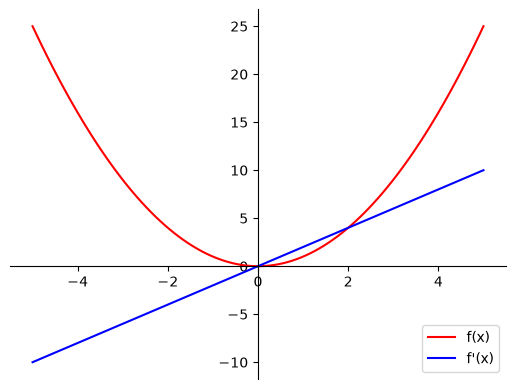

In [35]:
plot_f1_and_f2(f, vmap(grad(f)))

In [36]:
import timeit, time

x_array_large = np.linspace(-5, 5, 1000000)

tic_symb = time.time()
res_symb = lambdify(x, diff(f(x),x),'numpy')(x_array_large)
toc_symb = time.time()
time_symb = 1000 * (toc_symb - tic_symb)  # Time in ms.

tic_numerical = time.time()
res_numerical = np.gradient(f(x_array_large),x_array_large)
toc_numerical = time.time()
time_numerical = 1000 * (toc_numerical - tic_numerical)

tic_jax = time.time()
res_jax = vmap(grad(f))(jnp.array(x_array_large.astype('float32')))
toc_jax = time.time()
time_jax = 1000 * (toc_jax - tic_jax)

print(f"Results\nSymbolic Differentiation:\n{res_symb}\n" + 
      f"Numerical Differentiation:\n{res_numerical}\n" + 
      f"Automatic Differentiation:\n{res_jax}")

print(f"\n\nTime\nSymbolic Differentiation:\n{time_symb} ms\n" + 
      f"Numerical Differentiation:\n{time_numerical} ms\n" + 
      f"Automatic Differentiation:\n{time_jax} ms")

Results
Symbolic Differentiation:
[-10.       -9.99998  -9.99996 ...   9.99996   9.99998  10.     ]
Numerical Differentiation:
[-9.99999 -9.99998 -9.99996 ...  9.99996  9.99998  9.99999]
Automatic Differentiation:
[-10.       -9.99998  -9.99996 ...   9.99996   9.99998  10.     ]


Time
Symbolic Differentiation:
4.341840744018555 ms
Numerical Differentiation:
34.57450866699219 ms
Automatic Differentiation:
56.172847747802734 ms
